# Understanding DBSCAN Galaxy Columns

In [23]:
import opencosmo as oc
import matplotlib.pyplot as plt
from astropy import units as u

## What is DBSCAN?

If you take a look at the columns contained in a galaxy properties file, you may notice that there are columns labeled with `DBSCAN`. Uncomment the line below and run the cell to see all of the columns in the dataset. Try to find all the columns with this label.

What we have done in the cell below is use `.open()` to read in our galaxy file, use `.take()` to get the data of 1 galaxy at random, and use `.get_data()` to get a dictionary with all the columns associated with that galaxy. We didn't have to take 1 galaxy, but reducing the data in this way speeds up the cell's execution.

In [3]:
data = oc.open('filtered_galaxy_catalog.hdf5')
# data.take(1, at='random').get_data()

You should have found 3 different columns:
- `gal_dbscan_mstar`
- `gal_dbscan_radius`
- `gal_dbscan_count`

To understand what these mean, we first need to understand how galaxies are found within the simulation. In this case, galaxies are found by running a clustering algorithm, named DBSCAN (Density-Based Spatial Clustering of Applications with Noise), on the star particles of the simulation. However, each column of the dataset is not computed from the DBSCAN cluster, it is instead calculated based on the star particles that lie within a given aperture centered on the DBSCAN cluster. The process goes something like this:

1. Run DBSCAN on all the star particles to find clusters.
2. Calculate the center of each cluster, taken to be the potential minimum of the star particles
3. Place an aperture around the center of each cluster, 50 kpc was used in this case
4. Compute desired quantities and save them under the correct column.

You can think of the DBSCAN clusters as a type of "raw output" from the simulation, where after some post-processing, we get the values reported in the dataset. Let's look at those columns again and give them proper definitions:

- `gal_dbscan_mstar`: stellar mass from all star particles contained in the cluster
- `gal_dbscan_radius`: The distance between the center of the cluster and the furthest star particle in the cluster
- `gal_dbscan_count`: Number of star particles contained in the DBSCAN group.

Making visualizations of the difference between DBSCAN and aperture galaxies is difficult because a galaxy particles file will only contain the star particles that lie within the aperture. Instead, lets just plot these 3 columns in specific ways that will help us get a sense of how different the DBSCAN clusters are compared to their aperture counterparts.

## Stellar Mass

Let's start with stellar mass. Let's grab the DBSCAN mass column, and the aperture mass column (`gal_mass_star`), and plot the ratio. Below we will use `.select()` to only extract the column we want for the data. It's important to do this step before using `.get_data()`, so you don't load the full dataset at once.

The lowest value of the DBSCAN/Aperture ratio is  1.0  and the largest is  11.205097198486328


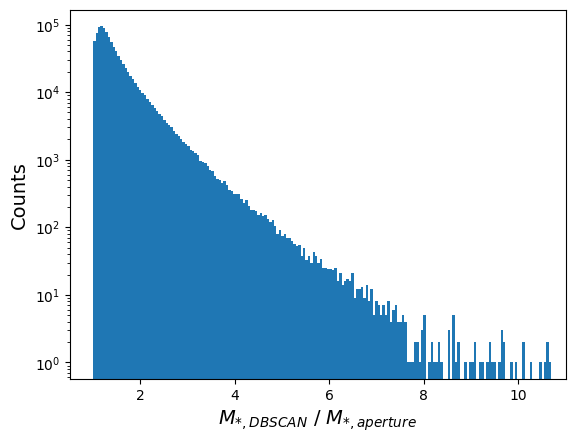

In [15]:
M_db = data.select('gal_dbscan_mstar').get_data()
M_ap = data.select('gal_mass_star').get_data()
ratio = M_db/M_ap

print('The lowest value of the DBSCAN/Aperture ratio is ', ratio.min(),' and the largest is ', ratio.max())

plt.hist(ratio, bins = 200)
plt.xlabel('$M_{*,DBSCAN}$ / $M_{*,aperture}$', fontsize = 14)
plt.ylabel('Counts', fontsize = 14)
plt.yscale('log')
plt.xlim(0.5, 11)
plt.show()

A ratio of 1 means that every particle in the DBSCAN cluster is contained within the 50 kpc aperture. It's a good sign that most galaxies lie at or around a ratio of 1, implying that the aperture represnts the original cluster well. However, we also see ratios can get as large as 11, with hundreds of galaxies seemingly at a ratio of 4 or higher. What do you think can cause such large discrepancies in the data? Can you discern what types of galaxies are more likely to have larger DBSCAN masses?

One reason for these large ratios is **Overlinking**, where the DBSCAN algorithm links together multiple galaxies that should be identified separately. This can happen during an active merger, where the boundaries of the two galaxies can get blurred, but it can also happen for massive central galaxies in galaxy clusters. The ICL can act as a bridge that links multiple galaxies together if it is dense enough. As evidence of this, let's look at the mass ratio as a function of the aperture mass.

To look at the ratio as a function of mass, we will have to use `.filter()` to restrict our dataset to the mass range we want. It is important to filter before selecting the column because `.select()` will get rid of every column we don't explicitly ask for, even the one we are trying to filter on! Note that filtering works as one would expect using standard Python syntax, however we use `.col()` to refer to specific columns in the dataset.

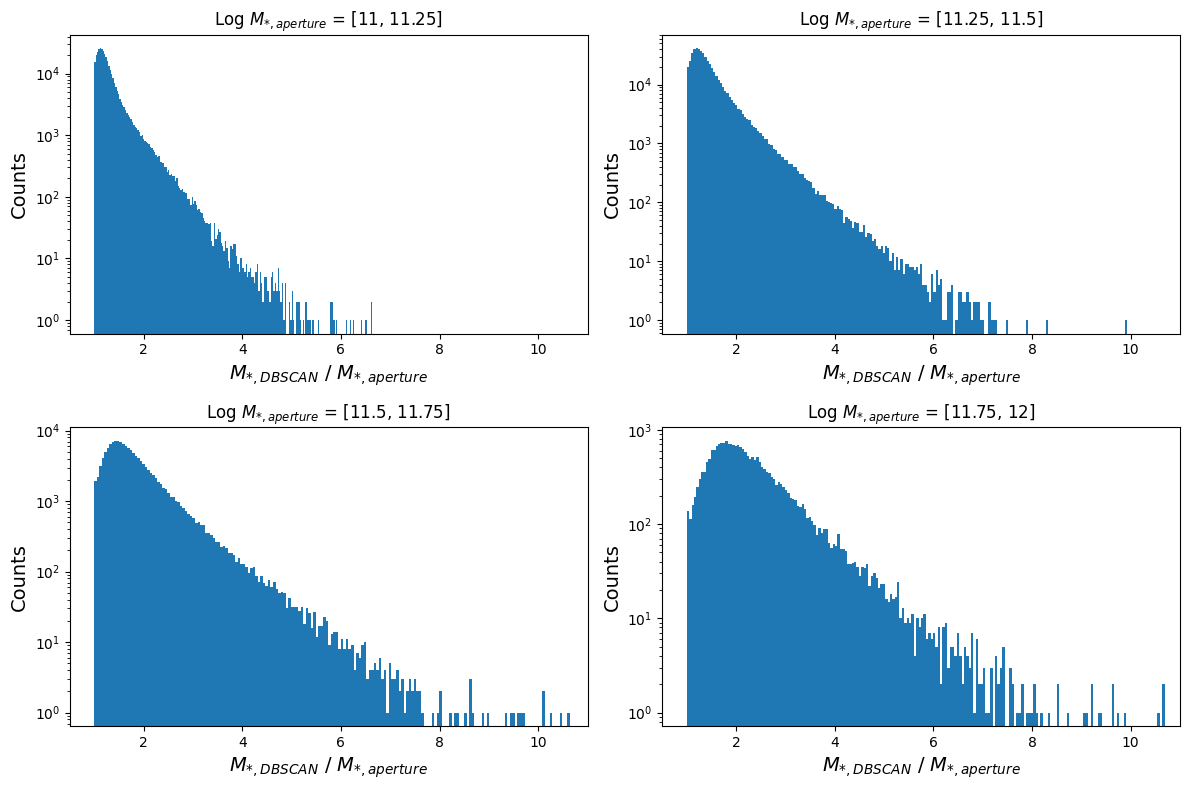

In [20]:
bins = [11, 11.25, 11.5, 11.75, 12]

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for ind, ax in enumerate(axs.flatten()):
    
    mask = (oc.col('gal_mass_star') < 10**bins[ind+1]) & (oc.col('gal_mass_star') > 10**bins[ind])
    M_db = data.filter(mask).select('gal_dbscan_mstar').get_data()
    M_ap = data.filter(mask).select('gal_mass_star').get_data()
    ratio = M_db/M_ap
    
    ax.hist(ratio, bins = 200)
    ax.set_xlabel('$M_{*,DBSCAN}$ / $M_{*,aperture}$', fontsize = 14)
    ax.set_ylabel('Counts', fontsize = 14)
    ax.set_title('Log $M_{*,aperture}$ = ' + f'[{bins[ind]}, {bins[ind+1]}]')
    ax.set_yscale('log')
    ax.set_xlim(0.5, 11)

plt.tight_layout()
plt.show()

Notice how both the peak and tail of the distribution shifts towards larger mass ratios!

## Galaxy Radius

Given the results above for mass, what do you think will happen when we investigate the size of the clusters? We can make a similar histogram using the fixed size of the aperture:

The lowest value of the DBSCAN/Aperture ratio is  0.7453400641679764  and the largest is  47.50483512878418


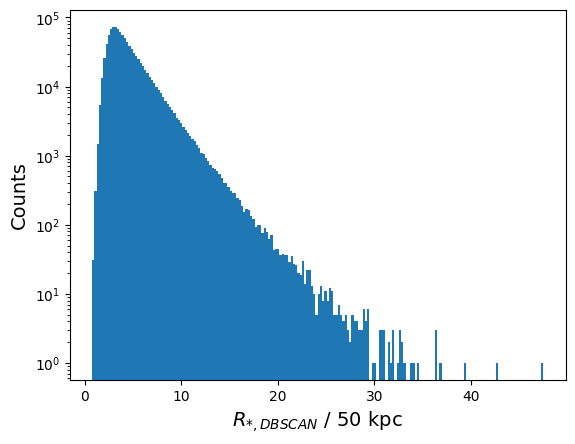

In [ ]:
R_db = data.select('gal_dbscan_radius').get_data()
ratio = R_db/(0.05*u.Mpc)

print('The lowest value of the DBSCAN/Aperture ratio is ', ratio.min(),' and the largest is ', ratio.max())

plt.hist(ratio, bins = 200)
plt.xlabel('$R_{*,DBSCAN}$ / 50 kpc', fontsize = 14)
plt.ylabel('Counts', fontsize = 14)
plt.yscale('log')
plt.show()

We get a similar result as above, ratio values below 1 repesent DBSCAN clusters that are fully contained within their aperture, and ratios greater than one means that the cluster extends past the aperture. As before, let's also look at this plot in different mass bins

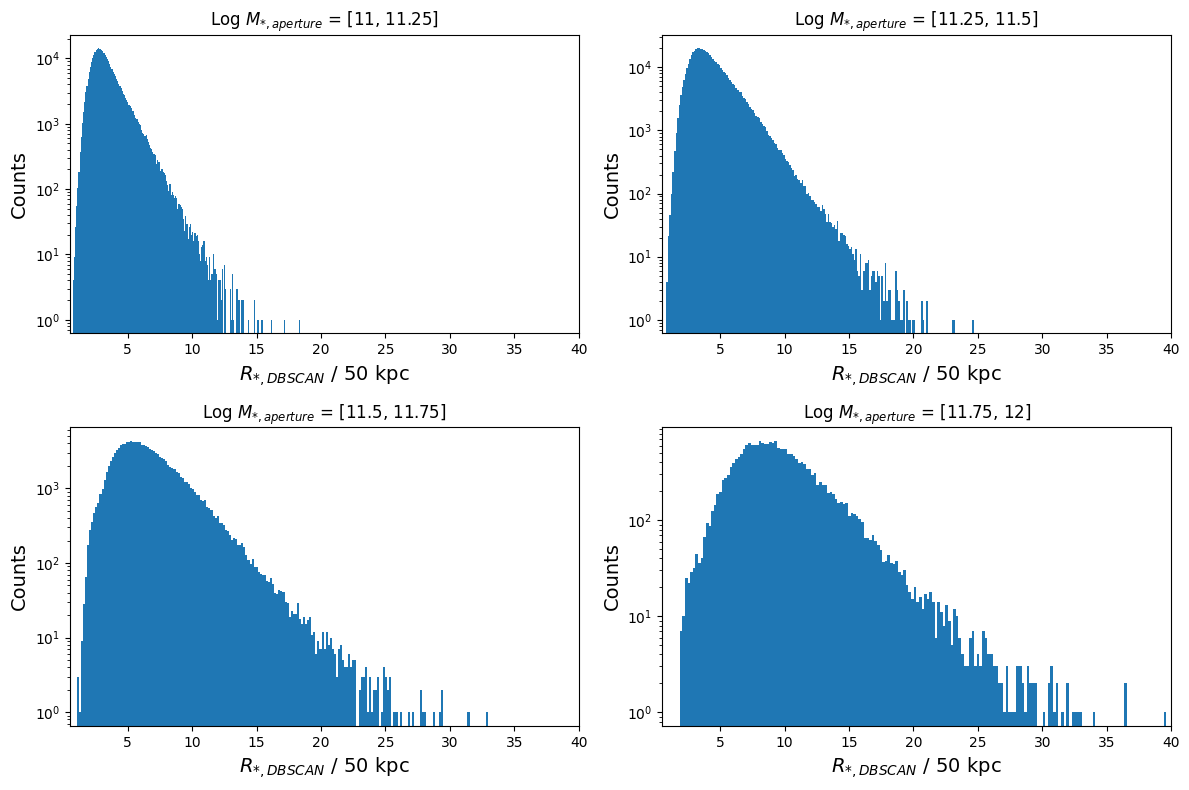

In [27]:
bins = [11, 11.25, 11.5, 11.75, 12]

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for ind, ax in enumerate(axs.flatten()):
    
    mask = (oc.col('gal_mass_star') < 10**bins[ind+1]) & (oc.col('gal_mass_star') > 10**bins[ind])
    R_db = data.filter(mask).select('gal_dbscan_radius').get_data()
    ratio = R_db/(0.05*u.Mpc)
    
    ax.hist(ratio, bins = 200)
    ax.set_xlabel('$R_{*,DBSCAN}$ / 50 kpc', fontsize = 14)
    ax.set_ylabel('Counts', fontsize = 14)
    ax.set_title('Log $M_{*,aperture}$ = ' + f'[{bins[ind]}, {bins[ind+1]}]')
    ax.set_yscale('log')
    ax.set_xlim(0.5, 40)

plt.tight_layout()
plt.show()

Just like for the mass ratio, the peak and tail shift to higher values as we increase mass. This is also clear evidence of overlinking because the extent of your cluster will be significantly more than a 50 kpc aperture if it contains multiple linked galaxies.

> **What about `gal_dbscan_count`?**
>
> Given that the mass of each galaxy comes from summing the mass of its star particles, we will get very similar results if we look at the ratio of particle count. Feel free to make those plots as an excercise for yourself, but we will not plot them here for brevity.

The takeaway here, is that one should be careful when using the properties of very massive galaxies as overlinking may influence the reported mass and size of the galaxy. For most use cases, the effects of overlinking is small and can be ignored, but for more complex analyses it should be taken into account!